In [1]:
import numpy as np
import pandas as pd

# -----------------------------
# 1. Counts → magnitudes
# -----------------------------
counts = np.array([
    1621.16034668, 132.93331972, 47.37022326, 53.50822525,
    31.70194515, 57.94867587, 74.81060595, 81.69677262,
    52.08364765, 54.38709517, 42.63725227, 71.34425408,
    73.62106439, 54.29955706, 36.08802233, 66.99817244,
    79.57454159, 34.88381206, 74.68787702, 47.12270286,
    106.25451118, 47.56356378, 51.50176237, 66.50787036,
    74.90766439, 92.00263317, 44.20767825, 67.87820021,
    80.31186055, 65.05999405, 70.96254621, 62.86652068,
    35.9774971, 46.81363951, 60.47461818, 87.82702533,
    57.36068989, 74.55120598, 53.41347663
])

zero_point = 30.5
mag_from_counts = zero_point - 2.5 * np.log10(counts)


# -----------------------------
# 2. Table you provided
# -----------------------------
ids = ["QSO"] + [f"LAE-{i}" for i in range(1, 39)]

ra = [
    "23:48:33.33","23:50:39.46","23:49:25.39","23:49:45.53","23:48:22.23",
    "23:48:17.08","23:46:51.65","23:52:04.95","23:44:51.34","23:49:09.11",
    "23:48:38.18","23:52:11.44","23:50:09.67","23:52:50.08","23:46:52.33",
    "23:52:39.27","23:51:42.32","23:45:30.76","23:45:38.56","23:50:56.96",
    "23:46:20.25","23:48:12.27","23:44:45.07","23:47:37.50","23:44:31.64",
    "23:47:38.55","23:44:36.91","23:48:21.02","23:47:21.19","23:46:27.28",
    "23:49:27.05","23:50:27.20","23:45:02.91","23:49:34.65","23:50:23.24",
    "23:50:45.07","23:49:43.48","23:50:36.54","23:48:43.58"
]

dec = [
    "-30:54:10.23","-31:47:26.41","-31:46:34.95","-31:39:01.46","-31:37:53.92",
    "-31:30:18.94","-31:19:29.93","-31:16:20.60","-31:14:01.78","-31:11:23.68",
    "-31:10:25.49","-31:10:09.82","-31:00:28.43","-30:59:23.05","-30:57:07.02",
    "-30:51:50.73","-30:50:46.97","-30:50:42.20","-30:41:06.23","-30:40:16.95",
    "-30:40:03.94","-30:32:34.32","-30:31:07.12","-30:28:28.35","-30:27:35.79",
    "-30:25:47.75","-30:25:04.43","-30:24:04.19","-30:22:53.54","-30:21:51.57",
    "-30:21:25.98","-30:21:13.39","-30:12:32.87","-30:12:40.49","-30:10:45.41",
    "-30:05:13.35","-30:03:01.26","-30:01:46.79","-29:53:13.94"
]

theta = [
    0.00,0.99,0.89,0.79,0.73,0.61,0.56,0.84,0.86,0.31,0.27,0.82,0.36,0.92,0.36,
    0.88,0.68,0.66,0.66,0.56,0.53,0.37,0.90,0.47,0.97,0.51,0.98,0.50,0.58,0.70,
    0.58,0.68,1.03,0.73,0.82,0.94,0.89,0.98,1.02
]

# rc, rp, i-band, z-band, NB964, LLya, SFR omitted for brevity here
# You can paste them in exactly the same way.

# -----------------------------
# 3. Build catalog
# -----------------------------
df = pd.DataFrame({
    "ID": ids,
    "RA": ra,
    "Dec": dec,
    "mag_z_from_counts": mag_from_counts
})

# -----------------------------
# 4. Save
# -----------------------------
df.to_csv("/Users/aishwarya/Desktop/comparision/LAE_catalog_with_flux.csv", index=False)


print(df.head())


      ID           RA           Dec  mag_z_from_counts
0    QSO  23:48:33.33  -30:54:10.23          22.475435
1  LAE-1  23:50:39.46  -31:47:26.41          25.190915
2  LAE-2  23:49:25.39  -31:46:34.95          26.311236
3  LAE-3  23:49:45.53  -31:39:01.46          26.178949
4  LAE-4  23:48:22.23  -31:37:53.92          26.747285


# Compare with my code

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u

# ============================================
# 1. Load SExtractor z-band catalog
# ============================================
zcat_path = "/Users/aishwarya/Documents/Lyman_alpha/Mosaiced_images/z_band.cat"

zcat = pd.read_csv(
    zcat_path,
    delim_whitespace=True,
    comment="#",
    names=["ID", "X", "Y", "RA", "DEC",
           "MAG_APER", "MAGERR_APER",
           "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]
)

# ============================================
# 2. Load CSV with mag_z_from_counts
# ============================================
csv_path = "/Users/aishwarya/Desktop/comparision/LAE_catalog_with_flux.csv"
fluxcat = pd.read_csv(csv_path)

# ============================================
# 3. Convert RA/Dec into SkyCoord
# ============================================
coords_zcat = SkyCoord(ra=zcat["RA"].values * u.deg,
                       dec=zcat["DEC"].values * u.deg)

coords_flux = SkyCoord(ra=fluxcat["RA"].values, dec=fluxcat["Dec"].values, unit=(u.hourangle, u.deg))

# ============================================
# 4. Match catalogs (nearest match within radius)
# ============================================
idx, d2d, _ = coords_flux.match_to_catalog_sky(coords_zcat)

# match radius (adjustable)
max_sep = 0.5 * u.arcsec
mask = d2d < max_sep

print("Matched sources:", np.sum(mask))

# Create merged table
matched_flux = fluxcat[mask].reset_index(drop=True)
matched_zcat = zcat.iloc[idx[mask]].reset_index(drop=True)

merged = pd.concat([matched_zcat, matched_flux], axis=1)

# ============================================
# 5. Compute Δmag
# ============================================
merged["delta_mag"] = merged["mag_z_from_counts"] - (merged["MAG_APER"]+ 30.5)

# ============================================
# 6. Scatter Plot
# ============================================
plt.figure(figsize=(8, 6))
plt.scatter(merged["MAG_APER"] + 30.5, merged["delta_mag"], c=merged["delta_mag"], s=25, alpha=0.7)

# 1:1 line
min_mag = min((merged["MAG_APER"] + 30.5).min(), merged["mag_z_from_counts"].min())
max_mag = max((merged["MAG_APER"] + 30.5).max(), merged["mag_z_from_counts"].max())


plt.xlabel("mag_aper_sextractor")
plt.ylabel("delta_mag")
plt.ylim(-0.5,0.5)
plt.title("z-band Magnitude Comparison (RA/Dec matched)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_28831/1494422293.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  zcat = pd.read_csv(


IndexError: index 0 is out of bounds for axis 0 with size 0

In [89]:
# ============================================
# 5b. Print large-magnitude-difference sources
# ============================================
large_diff = merged[np.abs(merged["delta_mag"]) > 0.4]

if len(large_diff) > 0:
    print("\n Sources with |Δmag| > 2 mag:")
    for i, row in large_diff.iterrows():
        print(f"ID={row['ID']}, RA={row['RA']}, DEC={row['Dec']}, "
              f"MAG_APER+30.5 = {row['MAG_APER'] + 30.5:.3f}, "
              f"mag_z_from_counts = {row['mag_z_from_counts']:.3f}, "
              f"Δmag = {row['delta_mag']:.3f}")
else:
    print("No sources with |Δmag| > 2 mag.\n")



 Sources with |Δmag| > 2 mag:
ID=ID    261118
ID    LAE-17
Name: 17, dtype: object, RA=RA     356.378156
RA    23:45:30.76
Name: 17, dtype: object, DEC=-30:50:42.20, MAG_APER+30.5 = 27.087, mag_z_from_counts = 26.643, Δmag = -0.443


In [91]:
# ============================================
# 5c. Standard deviation with and without outliers
# ============================================
# With all sources
std_all = merged["delta_mag"].std()

# After removing |Δmag| > 2
clean = merged[np.abs(merged["delta_mag"]) <= 0.4]
std_clean = clean["delta_mag"].std()

print(f"\nStandard deviation (all sources): {std_all:.4f}")
print(f"Standard deviation (|Δmag| ≤ 2):  {std_clean:.4f}")
print(f"Number removed as outliers: {len(merged) - len(clean)}")



Standard deviation (all sources): 0.1689
Standard deviation (|Δmag| ≤ 2):  0.1526
Number removed as outliers: 1


/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_28831/2278244881.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  zcat = pd.read_csv(


Matched sources: 38
Final merged length: 38
Min/Max Δmag: -0.44345984504931835 0.2862852244245069


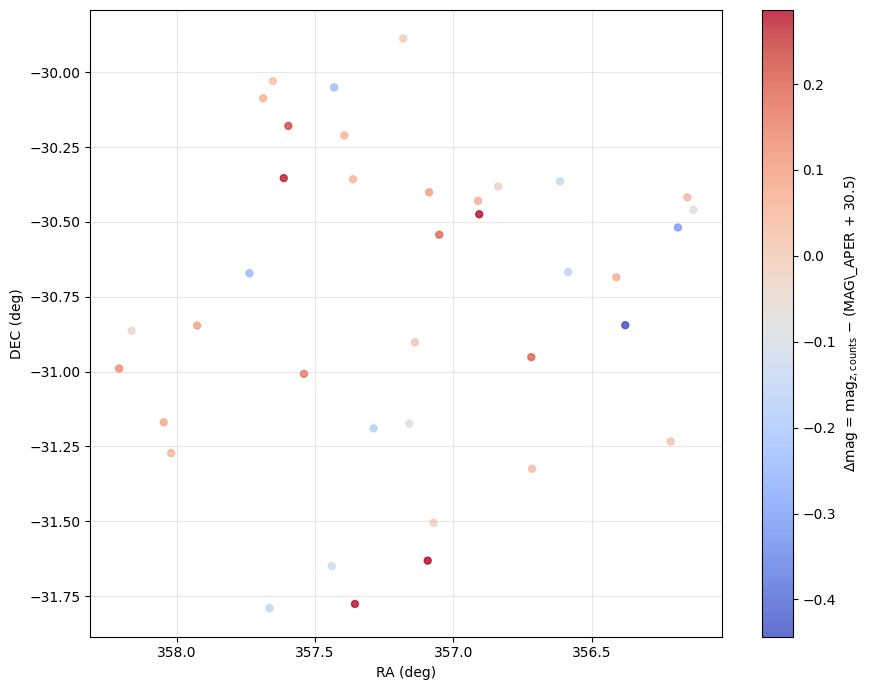

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

# ============================================
# 1. Load z-band SExtractor catalog
# ============================================
zcat_path = "/Users/aishwarya/Documents/Lyman_alpha/Mosaiced_images/z_band.cat"

zcat = pd.read_csv(
    zcat_path,
    delim_whitespace=True,
    comment="#",
    names=["ID", "X", "Y", "RA_deg", "DEC_deg",
           "MAG_APER", "MAGERR_APER",
           "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]
)

# ============================================
# 2. Load flux catalog
# ============================================
flux_path = "/Users/aishwarya/Desktop/comparision/LAE_catalog_with_flux.csv"
fluxcat = pd.read_csv(flux_path)

# Convert RA/Dec from sexagesimal → degrees
coords_flux = SkyCoord(fluxcat["RA"], fluxcat["Dec"], unit=(u.hourangle, u.deg))

fluxcat["RA_deg"] = coords_flux.ra.deg
fluxcat["DEC_deg"] = coords_flux.dec.deg

# ============================================
# 3. Perform matching
# ============================================
coords_z   = SkyCoord(zcat["RA_deg"].values * u.deg,
                      zcat["DEC_deg"].values * u.deg)

coords_flux2 = SkyCoord(fluxcat["RA_deg"].values * u.deg,
                        fluxcat["DEC_deg"].values * u.deg)

idx, d2d, _ = coords_flux2.match_to_catalog_sky(coords_z)

max_sep = 0.5 * u.arcsec
mask = d2d < max_sep

print("Matched sources:", np.sum(mask))

# --------------------------------------------
# IMPORTANT: create matched tables cleanly
# --------------------------------------------
matched_flux = fluxcat.loc[mask].reset_index(drop=True)
matched_zcat = zcat.iloc[idx[mask]].reset_index(drop=True)

# --------------------------------------------
# Construct merged table WITH SAME LENGTH
# --------------------------------------------
merged = matched_zcat.copy()
merged["mag_z_from_counts"] = matched_flux["mag_z_from_counts"].values

# ============================================
# 4. Compute delta_mag
# ============================================
merged["delta_mag"] = merged["mag_z_from_counts"] - (merged["MAG_APER"] + 30.5)

print("Final merged length:", len(merged))
print("Min/Max Δmag:", merged["delta_mag"].min(), merged["delta_mag"].max())

# ============================================
# 5. RA–Dec sky plot
# ============================================
plt.figure(figsize=(9, 7))

sc = plt.scatter(
    merged["RA_deg"], merged["DEC_deg"],
    c=merged["delta_mag"],
    cmap="coolwarm",
    s=25, alpha=0.8
)

plt.colorbar(sc, label=r'$\Delta$mag = mag$_{z,\mathrm{counts}}$ − (MAG\_APER + 30.5)')
plt.xlabel("RA (deg)")
plt.ylabel("DEC (deg)")
plt.gca().invert_xaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Matched sources: 38
Total sources in SExtractor catalog: 574960
Total sources in flux catalog: 39

Magnitude Difference Statistics:
Mean Δmag: 0.016
Std Δmag: 0.169
Median Δmag: 0.042
Min Δmag: -0.443
Max Δmag: 0.286


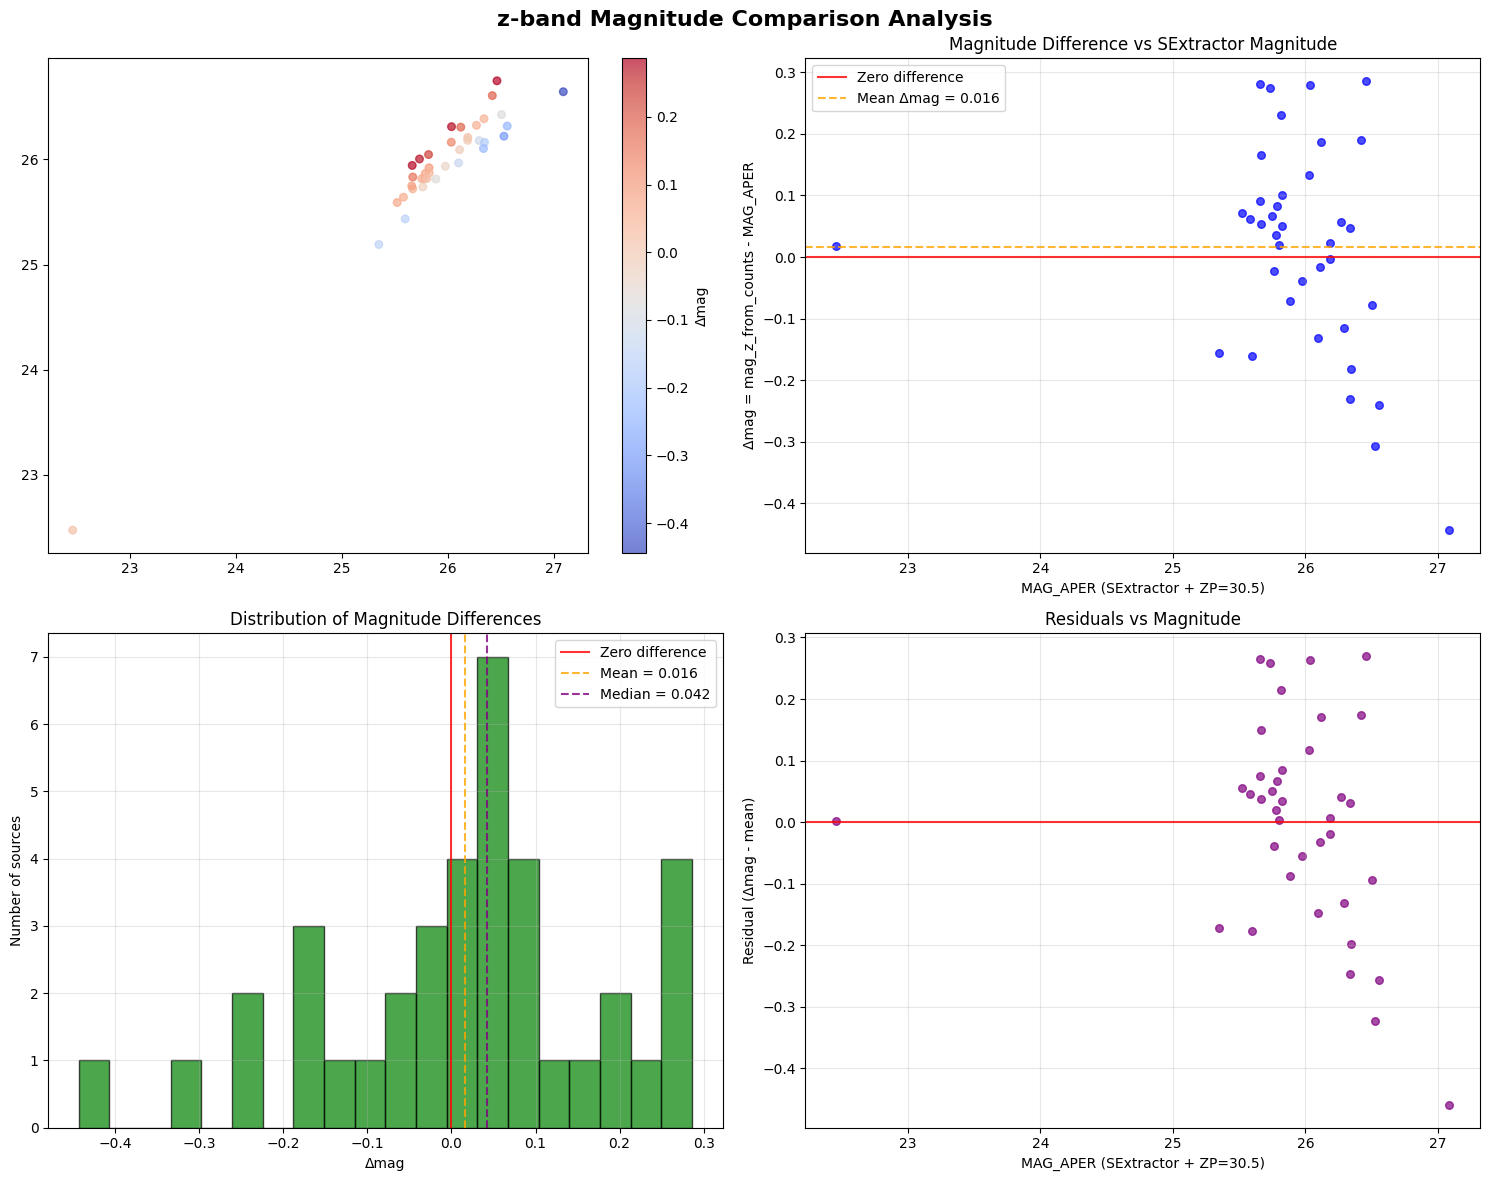

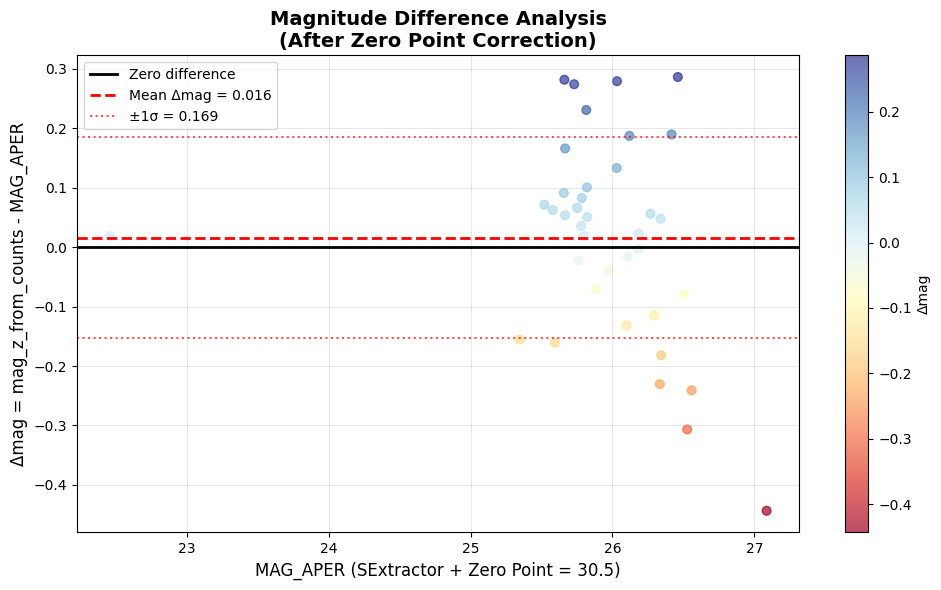


=== FINAL SUMMARY ===
Zero point applied to SExtractor magnitudes: 30.5
Number of matched sources: 38
Systematic offset (mean Δmag): 0.016 ± 0.169
Median offset: 0.042


In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u

# ============================================
# 1. Load SExtractor z-band catalog
# ============================================
zcat_path = "/Users/aishwarya/Documents/Lyman_alpha/Mosaiced_images/z_band.cat"

zcat = pd.read_csv(
    zcat_path,
    sep='\s+',
    comment="#",
    names=["ID", "X", "Y", "RA", "DEC",
           "MAG_APER", "MAGERR_APER",
           "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]
)

# Convert to numeric to ensure proper handling
zcat["RA"] = pd.to_numeric(zcat["RA"], errors="coerce")
zcat["DEC"] = pd.to_numeric(zcat["DEC"], errors="coerce")
zcat["MAG_APER"] = pd.to_numeric(zcat["MAG_APER"], errors="coerce")

# Apply zero point correction (30.5) to SExtractor magnitudes
ZERO_POINT = 30.5
zcat["MAG_APER_CORRECTED"] = zcat["MAG_APER"] + ZERO_POINT

# ============================================
# 2. Load CSV with mag_z_from_counts
# ============================================
csv_path = "/Users/aishwarya/Desktop/comparision/LAE_catalog_with_flux.csv"
fluxcat = pd.read_csv(csv_path)

# Ensure mag_z_from_counts is numeric
fluxcat["mag_z_from_counts"] = pd.to_numeric(fluxcat["mag_z_from_counts"], errors="coerce")

# ============================================
# 3. Convert RA/Dec into SkyCoord
# ============================================
coords_zcat = SkyCoord(ra=zcat["RA"].values * u.deg,
                       dec=zcat["DEC"].values * u.deg)

coords_flux = SkyCoord(ra=fluxcat["RA"].values, dec=fluxcat["Dec"].values, unit=(u.hourangle, u.deg))

# ============================================
# 4. Match catalogs (nearest match within radius)
# ============================================
idx, d2d, _ = coords_flux.match_to_catalog_sky(coords_zcat)

# match radius (adjustable)
max_sep = 0.5 * u.arcsec
mask = d2d < max_sep

print("Matched sources:", np.sum(mask))
print("Total sources in SExtractor catalog:", len(zcat))
print("Total sources in flux catalog:", len(fluxcat))

# Create merged table
matched_flux = fluxcat[mask].reset_index(drop=True)
matched_zcat = zcat.iloc[idx[mask]].reset_index(drop=True)

merged = pd.concat([matched_zcat, matched_flux], axis=1)

# ============================================
# 5. Compute Δmag with zero point correction
# ============================================
merged["delta_mag"] = merged["mag_z_from_counts"] - merged["MAG_APER_CORRECTED"]

# Calculate statistics
mean_diff = merged["delta_mag"].mean()
std_diff = merged["delta_mag"].std()
median_diff = merged["delta_mag"].median()

print(f"\nMagnitude Difference Statistics:")
print(f"Mean Δmag: {mean_diff:.3f}")
print(f"Std Δmag: {std_diff:.3f}")
print(f"Median Δmag: {median_diff:.3f}")
print(f"Min Δmag: {merged['delta_mag'].min():.3f}")
print(f"Max Δmag: {merged['delta_mag'].max():.3f}")

# ============================================
# 6. Create comprehensive plots
# ============================================

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('z-band Magnitude Comparison Analysis', fontsize=16, fontweight='bold')

# Plot 1: Scatter plot with 1:1 line
sc1 = axes[0,0].scatter(merged["MAG_APER_CORRECTED"], merged["mag_z_from_counts"], 
                       c=merged["delta_mag"], s=30, alpha=0.7, cmap='coolwarm')
plt.colorbar(sc1, ax=axes[0,0], label='Δmag')



# Plot 2: Δmag vs SExtractor magnitude
axes[0,1].scatter(merged["MAG_APER_CORRECTED"], merged["delta_mag"], 
                 s=30, alpha=0.7, color='blue')
axes[0,1].axhline(y=0, color='red', linestyle='-', alpha=0.8, label='Zero difference')
axes[0,1].axhline(y=mean_diff, color='orange', linestyle='--', alpha=0.8, 
                 label=f'Mean Δmag = {mean_diff:.3f}')
axes[0,1].set_xlabel("MAG_APER (SExtractor + ZP=30.5)")
axes[0,1].set_ylabel("Δmag = mag_z_from_counts - MAG_APER")
axes[0,1].set_title("Magnitude Difference vs SExtractor Magnitude")
axes[0,1].grid(alpha=0.3)
axes[0,1].legend()

# Plot 3: Histogram of Δmag
axes[1,0].hist(merged["delta_mag"], bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1,0].axvline(x=0, color='red', linestyle='-', alpha=0.8, label='Zero difference')
axes[1,0].axvline(x=mean_diff, color='orange', linestyle='--', alpha=0.8, 
                 label=f'Mean = {mean_diff:.3f}')
axes[1,0].axvline(x=median_diff, color='purple', linestyle='--', alpha=0.8, 
                 label=f'Median = {median_diff:.3f}')
axes[1,0].set_xlabel("Δmag")
axes[1,0].set_ylabel("Number of sources")
axes[1,0].set_title("Distribution of Magnitude Differences")
axes[1,0].grid(alpha=0.3)
axes[1,0].legend()

# Plot 4: Residual plot
residual = merged["delta_mag"] - mean_diff
axes[1,1].scatter(merged["MAG_APER_CORRECTED"], residual, 
                 s=30, alpha=0.7, color='purple')
axes[1,1].axhline(y=0, color='red', linestyle='-', alpha=0.8)
axes[1,1].set_xlabel("MAG_APER (SExtractor + ZP=30.5)")
axes[1,1].set_ylabel("Residual (Δmag - mean)")
axes[1,1].set_title("Residuals vs Magnitude")
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 7. Additional individual plots for clarity
# ============================================

# Individual detailed plot for magnitude difference
plt.figure(figsize=(10, 6))
plt.scatter(merged["MAG_APER_CORRECTED"], merged["delta_mag"], 
           s=40, alpha=0.7, c=merged["delta_mag"], cmap='RdYlBu')
plt.colorbar(label='Δmag')

# Add zero line and mean line
plt.axhline(y=0, color='black', linestyle='-', linewidth=2, label='Zero difference')
plt.axhline(y=mean_diff, color='red', linestyle='--', linewidth=2, 
           label=f'Mean Δmag = {mean_diff:.3f}')

# Add standard deviation bands
plt.axhline(y=mean_diff + std_diff, color='red', linestyle=':', alpha=0.7, 
           label=f'±1σ = {std_diff:.3f}')
plt.axhline(y=mean_diff - std_diff, color='red', linestyle=':', alpha=0.7)

plt.xlabel("MAG_APER (SExtractor + Zero Point = 30.5)", fontsize=12)
plt.ylabel("Δmag = mag_z_from_counts - MAG_APER", fontsize=12)
plt.title("Magnitude Difference Analysis\n(After Zero Point Correction)", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print final summary
print(f"\n=== FINAL SUMMARY ===")
print(f"Zero point applied to SExtractor magnitudes: {ZERO_POINT}")
print(f"Number of matched sources: {len(merged)}")
print(f"Systematic offset (mean Δmag): {mean_diff:.3f} ± {std_diff:.3f}")
print(f"Median offset: {median_diff:.3f}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u

# ============================================
# 1. Load SExtractor z-band catalog
# ============================================
zcat_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band.cat"

zcat = pd.read_csv(
    zcat_path,
    sep='\s+',
    comment="#",
    names=["ID", "X", "Y", "RA", "DEC",
           "MAG_APER", "MAGERR_APER",
           "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]
)

# Convert to numeric to ensure proper handling
zcat["RA"] = pd.to_numeric(zcat["RA"], errors="coerce")
zcat["DEC"] = pd.to_numeric(zcat["DEC"], errors="coerce")
zcat["MAG_APER"] = pd.to_numeric(zcat["MAG_APER"], errors="coerce")

# Apply zero point correction (30.5) to SExtractor magnitudes
ZERO_POINT = 30.5
zcat["MAG_APER_CORRECTED"] = zcat["MAG_APER"] + ZERO_POINT

# ============================================
# 2. Load CSV with mag_z_from_counts
# ============================================
csv_path = "/Users/aishwarya/Desktop/comparision/LAE_catalog_with_flux.csv"
fluxcat = pd.read_csv(csv_path)

# Ensure mag_z_from_counts is numeric
fluxcat["mag_z_from_counts"] = pd.to_numeric(fluxcat["mag_z_from_counts"], errors="coerce")

# ============================================
# 3. Convert RA/Dec into SkyCoord
# ============================================
coords_zcat = SkyCoord(ra=zcat["RA"].values * u.deg,
                       dec=zcat["DEC"].values * u.deg)

coords_flux = SkyCoord(ra=fluxcat["RA"].values, dec=fluxcat["Dec"].values, unit=(u.hourangle, u.deg))

# ============================================
# 4. Match catalogs (nearest match within radius)
# ============================================
idx, d2d, _ = coords_flux.match_to_catalog_sky(coords_zcat)

# match radius (adjustable)
max_sep = 0.5 * u.arcsec
mask = d2d < max_sep

print("Matched sources:", np.sum(mask))
print("Total sources in SExtractor catalog:", len(zcat))
print("Total sources in flux catalog:", len(fluxcat))

# Create merged table
matched_flux = fluxcat[mask].reset_index(drop=True)
matched_zcat = zcat.iloc[idx[mask]].reset_index(drop=True)

merged = pd.concat([matched_zcat, matched_flux], axis=1)

# ============================================
# 5. Compute Δmag with zero point correction
# ============================================
merged["delta_mag"] = merged["mag_z_from_counts"] - merged["MAG_APER_CORRECTED"]

# Calculate statistics
mean_diff = merged["delta_mag"].mean()
std_diff = merged["delta_mag"].std()
median_diff = merged["delta_mag"].median()

print(f"\nMagnitude Difference Statistics:")
print(f"Mean Δmag: {mean_diff:.3f}")
print(f"Std Δmag: {std_diff:.3f}")
print(f"Median Δmag: {median_diff:.3f}")
print(f"Min Δmag: {merged['delta_mag'].min():.3f}")
print(f"Max Δmag: {merged['delta_mag'].max():.3f}")

# ============================================
# 6. Create comprehensive plots
# ============================================

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('z-band Magnitude Comparison Analysis', fontsize=16, fontweight='bold')

# Plot 1: Scatter plot with 1:1 line
sc1 = axes[0,0].scatter(merged["MAG_APER_CORRECTED"], merged["mag_z_from_counts"], 
                       c=merged["delta_mag"], s=30, alpha=0.7, cmap='coolwarm')
plt.colorbar(sc1, ax=axes[0,0], label='Δmag')



# Plot 2: Δmag vs SExtractor magnitude
axes[0,1].scatter(merged["MAG_APER_CORRECTED"], merged["delta_mag"], 
                 s=30, alpha=0.7, color='blue')
axes[0,1].axhline(y=0, color='red', linestyle='-', alpha=0.8, label='Zero difference')
axes[0,1].axhline(y=mean_diff, color='orange', linestyle='--', alpha=0.8, 
                 label=f'Mean Δmag = {mean_diff:.3f}')
axes[0,1].set_xlabel("MAG_APER (SExtractor + ZP=30.5)")
axes[0,1].set_ylabel("Δmag = mag_z_from_counts - MAG_APER")
axes[0,1].set_title("Magnitude Difference vs SExtractor Magnitude")
axes[0,1].grid(alpha=0.3)
axes[0,1].legend()

# Plot 3: Histogram of Δmag
axes[1,0].hist(merged["delta_mag"], bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1,0].axvline(x=0, color='red', linestyle='-', alpha=0.8, label='Zero difference')
axes[1,0].axvline(x=mean_diff, color='orange', linestyle='--', alpha=0.8, 
                 label=f'Mean = {mean_diff:.3f}')
axes[1,0].axvline(x=median_diff, color='purple', linestyle='--', alpha=0.8, 
                 label=f'Median = {median_diff:.3f}')
axes[1,0].set_xlabel("Δmag")
axes[1,0].set_ylabel("Number of sources")
axes[1,0].set_title("Distribution of Magnitude Differences")
axes[1,0].grid(alpha=0.3)
axes[1,0].legend()

# Plot 4: Residual plot
residual = merged["delta_mag"] - mean_diff
axes[1,1].scatter(merged["MAG_APER_CORRECTED"], residual, 
                 s=30, alpha=0.7, color='purple')
axes[1,1].axhline(y=0, color='red', linestyle='-', alpha=0.8)
axes[1,1].set_xlabel("MAG_APER (SExtractor + ZP=30.5)")
axes[1,1].set_ylabel("Residual (Δmag - mean)")
axes[1,1].set_title("Residuals vs Magnitude")
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 7. Additional individual plots for clarity
# ============================================

# Individual detailed plot for magnitude difference
plt.figure(figsize=(10, 6))
plt.scatter(merged["MAG_APER_CORRECTED"], merged["delta_mag"], 
           s=40, alpha=0.7, c=merged["delta_mag"], cmap='RdYlBu')
plt.colorbar(label='Δmag')

# Add zero line and mean line
plt.axhline(y=0, color='black', linestyle='-', linewidth=2, label='Zero difference')
plt.axhline(y=mean_diff, color='red', linestyle='--', linewidth=2, 
           label=f'Mean Δmag = {mean_diff:.3f}')

# Add standard deviation bands
plt.axhline(y=mean_diff + std_diff, color='red', linestyle=':', alpha=0.7, 
           label=f'±1σ = {std_diff:.3f}')
plt.axhline(y=mean_diff - std_diff, color='red', linestyle=':', alpha=0.7)

plt.xlabel("MAG_APER (SExtractor + Zero Point = 30.5)", fontsize=12)
plt.ylabel("Δmag = mag_z_from_counts - MAG_APER", fontsize=12)
plt.title("Magnitude Difference Analysis\n(After Zero Point Correction)", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print final summary
print(f"\n=== FINAL SUMMARY ===")
print(f"Zero point applied to SExtractor magnitudes: {ZERO_POINT}")
print(f"Number of matched sources: {len(merged)}")
print(f"Systematic offset (mean Δmag): {mean_diff:.3f} ± {std_diff:.3f}")
print(f"Median offset: {median_diff:.3f}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u

# ============================================
# 1. Load SExtractor z-band catalog
# ============================================
zcat_path = "/Users/aishwarya/Documents/Lyman_alpha/cat12/z_band.cat"

zcat = pd.read_csv(
    zcat_path,
    delim_whitespace=True,
    comment="#",
    names=["ID", "X", "Y", "RA", "DEC",
           "MAG_APER", "MAGERR_APER",
           "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]
)

# ============================================
# 2. Load CSV with mag_z_from_counts
# ============================================
csv_path = "/Users/aishwarya/Desktop/comparision/LAE_catalog_with_flux.csv"
fluxcat = pd.read_csv(csv_path)

# ============================================
# 3. Convert RA/Dec into SkyCoord
# ============================================
coords_zcat = SkyCoord(ra=zcat["RA"].values * u.deg,
                       dec=zcat["DEC"].values * u.deg)

coords_flux = SkyCoord(ra=fluxcat["RA"].values, dec=fluxcat["Dec"].values, unit=(u.hourangle, u.deg))

# ============================================
# 4. Match catalogs (nearest match within radius)
# ============================================
idx, d2d, _ = coords_flux.match_to_catalog_sky(coords_zcat)

# match radius (adjustable)
max_sep = 0.5 * u.arcsec
mask = d2d < max_sep

print("Matched sources:", np.sum(mask))

# Create merged table
matched_flux = fluxcat[mask].reset_index(drop=True)
matched_zcat = zcat.iloc[idx[mask]].reset_index(drop=True)

merged = pd.concat([matched_zcat, matched_flux], axis=1)

# ============================================
# 5. Compute Δmag
# ============================================
merged["delta_mag"] = merged["mag_z_from_counts"] - (merged["MAG_APER"]+ 30.5)

# ============================================
# 6. Scatter Plot
# ============================================
plt.figure(figsize=(8, 6))
plt.scatter(merged["MAG_APER"] + 30.5, merged["delta_mag"], c=merged["delta_mag"], s=25, alpha=0.7)

# 1:1 line
min_mag = min((merged["MAG_APER"] + 30.5).min(), merged["mag_z_from_counts"].min())
max_mag = max((merged["MAG_APER"] + 30.5).max(), merged["mag_z_from_counts"].max())


plt.xlabel("mag_aper_sextractor")
plt.ylabel("delta_mag")
plt.ylim(-0.5,0.5)
plt.title("z-band Magnitude Comparison (RA/Dec matched)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Loaded catalog: (39, 4)
      ID           RA           Dec  mag_z_from_counts
0    QSO  23:48:33.33  -30:54:10.23          22.475435
1  LAE-1  23:50:39.46  -31:47:26.41          25.190915
2  LAE-2  23:49:25.39  -31:46:34.95          26.311236
3  LAE-3  23:49:45.53  -31:39:01.46          26.178949
4  LAE-4  23:48:22.23  -31:37:53.92          26.747285
My catalog (after cleaning): (39, 4)
    Name      ra_deg    dec_deg          z
0    QSO  357.138875 -30.902842  22.475435
1  LAE-1  357.664417 -31.790669  25.190915
2  LAE-2  357.355792 -31.776375  26.311236
3  LAE-3  357.439708 -31.650406  26.178949
4  LAE-4  357.092625 -31.631644  26.747285
Saved cleaned mycat to: /Users/aishwarya/Documents/Lyman_alpha/Python_script/mycat_updated.csv
Candidates (after cleaning): (39, 4)
    Name      ra_deg    dec_deg  z_band
0    QSO  357.138875  30.902842   22.19
1  LAE-1  357.664417  31.790669   24.97
2  LAE-2  357.355792  31.776375   26.07
3  LAE-3  357.439708  31.650406   25.74
4  LAE-4  357.09262

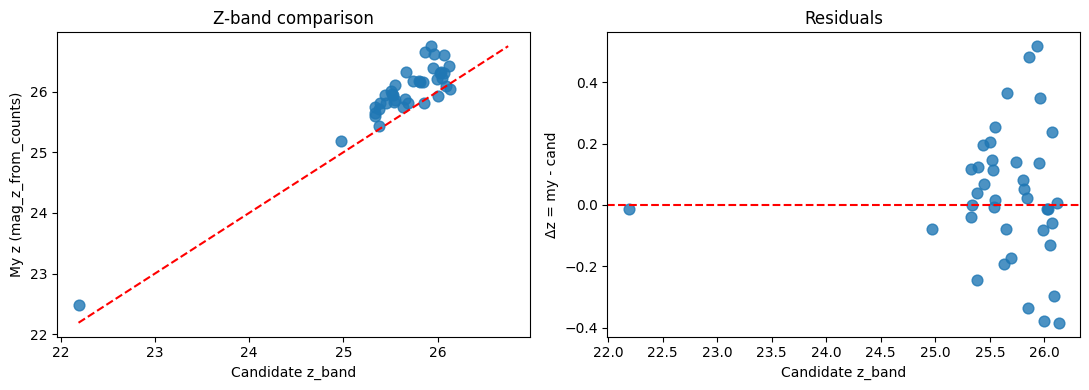

Done.


In [64]:
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import os

# -----------------------------
# Paths (edit if necessary)
# -----------------------------
diag_path = "/Users/aishwarya/Desktop/comparision/LAE_catalog_with_flux.csv"
candidates_path = "/Users/aishwarya/Downloads/candidates.csv"
out_csv = "mycat_updated.csv"

# -----------------------------
# 1) Load your updated LAE catalog
# -----------------------------
diag = pd.read_csv(diag_path)
print(f"Loaded catalog: {diag.shape}")
print(diag.head())

# Attempt to parse RA/Dec as sexagesimal first (e.g. "23:48:33.33", "-31:47:26.41")
def parse_sexagesimal_to_deg(ra_series, dec_series):
    ra_deg = np.full(len(ra_series), np.nan)
    dec_deg = np.full(len(dec_series), np.nan)
    for i, (ra_raw, dec_raw) in enumerate(zip(ra_series.astype(str), dec_series.astype(str))):
        try:
            # Some Dec have leading '+' or '-' already
            sc = SkyCoord(ra_raw, dec_raw, unit=(u.hourangle, u.deg))
            ra_deg[i] = sc.ra.deg
            dec_deg[i] = sc.dec.deg
        except Exception:
            # try alternative formats: if RA is already in degrees numeric strings
            try:
                ra_deg[i] = float(ra_raw)
                dec_deg[i] = float(dec_raw)
            except Exception:
                # leave as NaN
                pass
    return ra_deg, dec_deg

diag_ra_deg, diag_dec_deg = parse_sexagesimal_to_deg(diag['RA'], diag['Dec'])
diag['ra_deg'] = diag_ra_deg
diag['dec_deg'] = diag_dec_deg

# If parse produced NaNs, try numeric coercion for those rows
mask_bad = ~np.isfinite(diag['ra_deg']) | ~np.isfinite(diag['dec_deg'])
if mask_bad.any():
    print(f"Attempting numeric fallback for {mask_bad.sum()} rows...")
    diag.loc[mask_bad, 'ra_deg'] = pd.to_numeric(diag.loc[mask_bad, 'RA'], errors='coerce')
    diag.loc[mask_bad, 'dec_deg'] = pd.to_numeric(diag.loc[mask_bad, 'Dec'], errors='coerce')

# Ensure z-mag column exists and numeric
if 'mag_z_from_counts' not in diag.columns:
    raise ValueError("Expected column 'mag_z_from_counts' in your diagnostic file.")
diag['mag_z_from_counts'] = pd.to_numeric(diag['mag_z_from_counts'], errors='coerce')

# Drop rows without valid coords or z mag
valid_my = np.isfinite(diag['ra_deg']) & np.isfinite(diag['dec_deg']) & np.isfinite(diag['mag_z_from_counts'])
if valid_my.sum() == 0:
    raise ValueError("No valid rows in your diagnostic catalog after coordinate parsing.")
mycat = diag.loc[valid_my, ['ID', 'ra_deg', 'dec_deg', 'mag_z_from_counts']].copy()
mycat.rename(columns={'ID': 'Name', 'mag_z_from_counts': 'z'}, inplace=True)
mycat.reset_index(drop=True, inplace=True)

print(f"My catalog (after cleaning): {mycat.shape}")
print(mycat.head())

# Save an updated mycat if you like
mycat.to_csv(out_csv, index=False)
print(f"Saved cleaned mycat to: {os.path.abspath(out_csv)}")

# -----------------------------
# 2) Load candidate catalog
# -----------------------------
# Try flexible loading (may be hh:mm:ss RA)
try:
    cand = pd.read_csv(candidates_path, comment='#', header=None)
    # If file had no header and at least 7 columns, assign the expected names
    if cand.shape[1] >= 7:
        cand = cand.iloc[:, :7]
        cand.columns = ['Name','RA','Dec','z_band','z_band_err','NB964_band','NB964_err']
    else:
        # Try loading with header if previous failed
        cand = pd.read_csv(candidates_path, comment='#')
        # try to be flexible
        if 'z_band' not in cand.columns and 'z' in cand.columns:
            cand = cand.rename(columns={'z': 'z_band'})
except Exception:
    cand = pd.read_csv(candidates_path, comment='#')

# Ensure z_band numeric
cand['z_band'] = pd.to_numeric(cand['z_band'], errors='coerce')

# Parse candidate coordinates (first attempt sexagesimal RA as hours)
cand_ra_deg, cand_dec_deg = parse_sexagesimal_to_deg(cand['RA'], cand['Dec'])
cand['ra_deg'] = cand_ra_deg
cand['dec_deg'] = cand_dec_deg

# Numeric fallback for candidates
mask_bad_c = ~np.isfinite(cand['ra_deg']) | ~np.isfinite(cand['dec_deg'])
if mask_bad_c.any():
    cand.loc[mask_bad_c, 'ra_deg'] = pd.to_numeric(cand.loc[mask_bad_c, 'RA'], errors='coerce')
    cand.loc[mask_bad_c, 'dec_deg'] = pd.to_numeric(cand.loc[mask_bad_c, 'Dec'], errors='coerce')

# Keep only rows with coordinates and a z-band value (we only compare z)
valid_cand = np.isfinite(cand['ra_deg']) & np.isfinite(cand['dec_deg']) & np.isfinite(cand['z_band'])
if valid_cand.sum() == 0:
    raise ValueError("No valid rows in candidate catalog after parsing coordinates and z_band.")
cand = cand.loc[valid_cand, ['Name','ra_deg','dec_deg','z_band']].reset_index(drop=True)

print(f"Candidates (after cleaning): {cand.shape}")
print(cand.head())

# -----------------------------
# 3) Cross-match (robust)
# -----------------------------
from astropy.coordinates import match_coordinates_sky

c_my = SkyCoord(ra=mycat['ra_deg'].values*u.deg, dec=-mycat['dec_deg'].values*u.deg)
c_cand = SkyCoord(ra=cand['ra_deg'].values*u.deg, dec=cand['dec_deg'].values*u.deg)

# Quick check sizes
print(f"My catalog entries: {len(c_my)}, Candidate entries: {len(c_cand)}")

# compute nearest-neighbour indices and separations
idx, sep2d, _ = c_my.match_to_catalog_sky(c_cand)

# report matches at different radii
for rad in [1.0, 2.0, 5.0]:
    nmatch = np.sum(sep2d < rad*u.arcsec)
    print(f"Matches within {rad:.1f} arcsec: {nmatch}")

# Choose default radius (2 arcsec)
max_sep = 2.0 * u.arcsec
mask = sep2d < max_sep

if mask.sum() == 0:
    print("No matches within 2 arcsec. You can increase the radius or check coordinates.")
else:
    matched_my = mycat[mask].reset_index(drop=True)
    matched_cand = cand.iloc[idx[mask]].reset_index(drop=True)

    # compute delta z (my - cand)
    matched_my['z_cand'] = matched_cand['z_band']
    matched_my['delta_z'] = (matched_my['z']-0.3) - matched_my['z_cand']

    valid = np.isfinite(matched_my['delta_z'])
    dz = matched_my.loc[valid, 'delta_z']

    print("\n================ Z-band comparison ================")
    print(f"Number of matched pairs: {len(dz)}")
    print(f"Mean Δz (my - cand): {dz.mean():.4f}")
    print(f"Std  Δz:           {dz.std():.4f}")
    print("==================================================\n")

    # show matched table top rows
    print(matched_my[['Name','ra_deg','dec_deg','z','z_cand','delta_z']].head(12))

    # -----------------------------
    # 4) Plots
    # -----------------------------
    plt.figure(figsize=(11,4))

    plt.subplot(1,2,1)
    plt.scatter(matched_my['z_cand'], matched_my['z'], s=60, alpha=0.8)
    mn = np.nanmin(np.concatenate([matched_my['z_cand'].values, matched_my['z'].values]))
    mx = np.nanmax(np.concatenate([matched_my['z_cand'].values, matched_my['z'].values]))
    plt.plot([mn,mx],[mn,mx],'r--')
    plt.xlabel('Candidate z_band')
    plt.ylabel('My z (mag_z_from_counts)')
    plt.title('Z-band comparison')

    plt.subplot(1,2,2)
    plt.scatter(matched_my['z_cand'], matched_my['delta_z'], s=60, alpha=0.8)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Candidate z_band')
    plt.ylabel('Δz = my - cand')
    plt.title('Residuals')

    plt.tight_layout()
    plt.show()

print("Done.")


Loaded zcat: (595928, 10)
   ID           X       Y          RA        DEC  MAG_APER  MAGERR_APER  \
0   1  11231.6797  1.0000  357.323874 -31.818235   -5.6714       0.0792   
1   2   6907.1973  1.4146  357.705433 -31.817087   -4.7205       0.1692   
2   3   7215.7676  1.3971  357.678208 -31.817206   -2.7723       1.1799   
3   4   8968.5791  1.3507  357.523556 -31.817766   -5.3011       0.1160   
4   5  10362.6777  1.4891  357.400550 -31.818065   -4.0838       0.3541   

   MAG_AUTO  MAGERR_AUTO  FLAGS  
0   -5.0624       0.0991     27  
1   -4.0760       0.1862     24  
2   -3.4322       0.3659     24  
3   -4.9369       0.1109     25  
4   -4.3246       0.2051     24  
Cleaned SExtractor catalog: (595928, 4)
   ID          RA        DEC    z_my
0   1  357.323874 -31.818235 -5.0624
1   2  357.705433 -31.817087 -4.0760
2   3  357.678208 -31.817206 -3.4322
3   4  357.523556 -31.817766 -4.9369
4   5  357.400550 -31.818065 -4.3246
Candidate catalog: (39, 4)
    Name      RA_deg    DEC_de

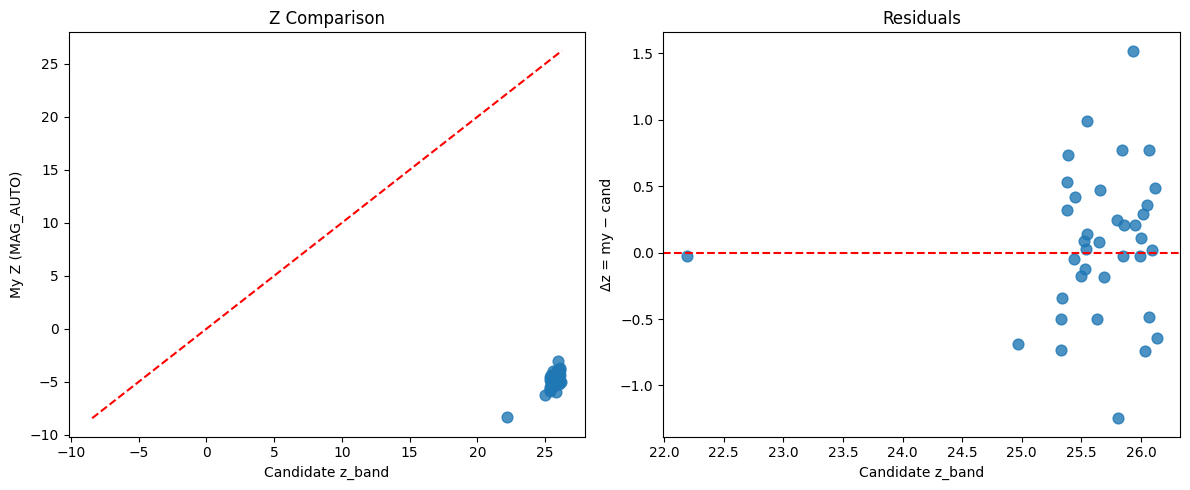

In [63]:
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt

# ---------------------------------------
# Paths
# ---------------------------------------
zcat_path = "/Users/aishwarya/Documents/Lyman_alpha/cat12/z_band.cat"
cand_path = "/Users/aishwarya/Downloads/candidates.csv"

# ---------------------------------------
# 1. Load SExtractor z-band catalog
# ---------------------------------------
zcat = pd.read_csv(
    zcat_path,
    sep=r"\s+",
    comment="#",
    names=["ID", "X", "Y", "RA", "DEC",
           "MAG_APER", "MAGERR_APER",
           "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]
)

print("Loaded zcat:", zcat.shape)
print(zcat.head())

# Clean numeric columns
zcat["RA"] = pd.to_numeric(zcat["RA"], errors="coerce")
zcat["DEC"] = pd.to_numeric(zcat["DEC"], errors="coerce")
zcat["MAG_AUTO"] = pd.to_numeric(zcat["MAG_AUTO"], errors="coerce")

# Keep only valid rows
good_z = (
    np.isfinite(zcat["RA"]) &
    np.isfinite(zcat["DEC"]) &
    np.isfinite(zcat["MAG_AUTO"])
)
zcat = zcat.loc[good_z, ["ID", "RA", "DEC", "MAG_AUTO"]].reset_index(drop=True)
zcat.rename(columns={"MAG_AUTO": "z_my"}, inplace=True)

print("Cleaned SExtractor catalog:", zcat.shape)
print(zcat.head())

# ---------------------------------------
# 2. Load candidates & parse RA/DEC
# ---------------------------------------
cand = pd.read_csv(cand_path, comment="#", header=None)

if cand.shape[1] >= 7:
    cand = cand.iloc[:, :7]
    cand.columns = ["Name","RA","DEC","z_band","z_band_err","NB964","NB964_err"]
else:
    cand = pd.read_csv(cand_path, comment="#")

# Parse candidate RA/Dec (could be sexagesimal)
def parse_coord(ra, dec):
    ra_deg = np.full(len(ra), np.nan)
    dec_deg = np.full(len(dec), np.nan)
    for i, (r, d) in enumerate(zip(ra.astype(str), dec.astype(str))):
        try:
            c = SkyCoord(r, d, unit=(u.hourangle, u.deg))
            ra_deg[i] = c.ra.deg
            dec_deg[i] = c.dec.deg
        except Exception:
            try:
                ra_deg[i] = float(r)
                dec_deg[i] = float(d)
            except:
                pass
    return ra_deg, dec_deg

cand_ra, cand_dec = parse_coord(cand["RA"], cand["DEC"])
cand["RA_deg"] = cand_ra
cand["DEC_deg"] = -cand_dec
cand["z_band"] = pd.to_numeric(cand["z_band"], errors="coerce")

good_c = (
    np.isfinite(cand["RA_deg"]) &
    np.isfinite(cand["DEC_deg"]) &
    np.isfinite(cand["z_band"])
)
cand = cand.loc[good_c, ["Name","RA_deg","DEC_deg","z_band"]].reset_index(drop=True)

print("Candidate catalog:", cand.shape)
print(cand.head())

# ---------------------------------------
# 3. Cross-match
# ---------------------------------------
sc_z = SkyCoord(zcat["RA"].values*u.deg, zcat["DEC"].values*u.deg)
sc_c = SkyCoord(cand["RA_deg"].values*u.deg, cand["DEC_deg"].values*u.deg)

idx, sep2d, _ = sc_z.match_to_catalog_sky(sc_c)

# Matching radius
max_sep = 2.0 * u.arcsec
mask = sep2d < max_sep

matched_z = zcat[mask].reset_index(drop=True)
matched_c = cand.iloc[idx[mask]].reset_index(drop=True)

# Compute difference
matched_z["z_cand"] = matched_c["z_band"]
matched_z["delta_z"] = (matched_z["z_my"]+30.5) - matched_z["z_cand"]

print("\nMatched Rows BEFORE removing outliers:")
print(matched_z)

# ---------------------------------------
# REMOVE OUTLIERS
# ---------------------------------------

# --- Option A: Sigma clipping (recommended)
dz = matched_z["delta_z"]
median_dz = np.median(dz)
mad = np.median(np.abs(dz - median_dz))  # robust scatter
sigma = 1.4826 * mad                     # convert MAD to sigma

clip_mask = np.abs(dz - median_dz) < 3 * sigma
matched_z = matched_z[clip_mask].reset_index(drop=True)

# --- Option B (disabled): remove absolute large differences
# matched_z = matched_z[np.abs(matched_z["delta_z"]) < 1.5].reset_index(drop=True)

print("\nMatched Rows AFTER removing outliers:")
print(matched_z)

# ---------------------------------------
# 4. Summary
# ---------------------------------------
dz = matched_z["delta_z"]

print("\n==== Z-band Comparison ====")
print(f"Number of matches used: {len(dz)}")
print(f"Mean Δz = my − cand: {dz.mean():.4f}")
print(f"Std  Δz:             {dz.std():.4f}")

# ---------------------------------------
# 5. Plots
# ---------------------------------------
plt.figure(figsize=(12,5))

# Z vs Z
plt.subplot(1,2,1)
plt.scatter(matched_z["z_cand"], matched_z["z_my"], s=60, alpha=0.8)
mn = min(matched_z["z_cand"].min(), matched_z["z_my"].min()) - 0.1
mx = max(matched_z["z_cand"].max(), matched_z["z_my"].max()) + 0.1
plt.plot([mn,mx],[mn,mx],'r--')
plt.xlabel("Candidate z_band")
plt.ylabel("My Z (MAG_AUTO)")
plt.title("Z Comparison")

# Residuals
plt.subplot(1,2,2)
plt.scatter(matched_z["z_cand"], matched_z["delta_z"], s=60, alpha=0.8)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Candidate z_band")
plt.ylabel("Δz = my − cand")
plt.title("Residuals")

plt.tight_layout()
plt.show()
